In [16]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from pathlib import Path
import sys; sys.path.insert(0, str(Path.cwd().parent / "src"))
from prediction.dataset import PREDICTOR_COLS, TARGET_CATEGORIES, build_model_table

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
# Build the Chicago and Houston crime tables
sns.set_theme(style="whitegrid")
hou = build_model_table("houston", refresh=True)
chi = build_model_table("chicago",refresh=True)
tables = {"houston": hou, "chicago": chi}   # already built above

Houston city boundary loaded: 1 row(s)
Houston state block groups loaded: 18,626
Block groups within city: 1,629 / 18,626


/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/core/geo_utils.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Houston crime data: 237,011 rows with valid coords (of 240,696)
Matched to BG: 236,917 | Unmatched: 94
Mapped: 132,286 / 237,011 (55.8%)
Category counts:
crime_category
larceny     67789
vandal      20426
assault     13041
mvt         12355
burglary    11284
robbery      4973
rape         1921
murder        289
fire          208

Unmapped: 104,725 records across 38 codes
BG-level category aggregation: 2,079 BGs (1,600 within city, 479 outside)
Crime Totals:
assault_count      13032.0
murder_count         288.0
rape_count          1921.0
robbery_count       4971.0
burglary_count     11284.0
larceny_count      67775.0
mvt_count          12349.0
vandal_count       20421.0
violent_count      20212.0
property_count     91408.0
cl_total_count    111620.0
dtype: float64
Analysis set: 2,108 BGs
  Inside city:  1,629 (1,600 with data, 29 without)
  Outside city: 479 (all with crime data)
Model loaded: 300,363 total BGs, 2,108 matched to analysis set
Merged comparison set: 2,108 BGs
  Inside cit

/home/eprashar_solutions_corelogic_com/crime-idx-2026/src/core/geo_utils.py:27: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  bg['centroid'] = bg.geometry.centroid


Chicago crime data: 235,767 rows with valid coords (of 237,207)
Matched to BG: 235,690 | Unmatched: 77
Mapped: 129,757 / 235,767 (55.0%)
Category counts:
crime_category
larceny     58322
vandal      26091
mvt         17164
assault     13640
burglary     6167
robbery      5780
rape         1792
murder        431
fire          370

Unmapped: 106,010 records across 15 codes
BG-level category aggregation: 2,256 BGs (2,164 within city, 92 outside)
Crime Totals:
assault_count      13636.0
murder_count         429.0
rape_count          1792.0
robbery_count       5775.0
burglary_count      6167.0
larceny_count      58295.0
mvt_count          17163.0
vandal_count       26081.0
violent_count      21632.0
property_count     81625.0
cl_total_count    103257.0
dtype: float64
Analysis set: 2,256 BGs
  Inside city:  2,164 (2,164 with data, 0 without)
  Outside city: 92 (all with crime data)
Model loaded: 300,363 total BGs, 2,256 matched to analysis set
Merged comparison set: 2,256 BGs
  Inside city: 

In [18]:
# Check percentile values of columns
def describe_cols(df, cols):
    d = df[cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
    d["skew"] = df[cols].skew()
    d["n_missing"] = df[cols].isna().sum()
    return d.round(2)

for city, df in tables.items():
    print(f"\n{'='*70}\n{city.upper()} — predictor summary\n{'='*70}")
    display(describe_cols(df, PREDICTOR_COLS))


HOUSTON — predictor summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing
det_pct,1629.0,47.52,37.42,0.00,0.00,0.00,7.73,45.96,84.84,100.00,100.00,100.00,0.08,0
in_household_pct,1629.0,98.91,5.96,0.00,76.72,96.87,99.51,100.00,100.00,100.00,100.00,100.00,-11.79,0
moved1yr_pct,1629.0,17.05,11.30,0.00,1.74,3.27,8.75,14.47,23.11,40.20,49.93,66.50,1.10,0
city_centers_dist,1629.0,19.64,8.73,1.00,10.00,10.00,15.00,20.00,20.00,30.00,50.00,50.00,1.72,0
pop_est_5mile,1629.0,404239.40,126370.44,57007.00,134393.36,187750.80,317643.00,395354.00,506825.00,603121.20,634320.56,642921.00,-0.11,0
pop_ch_1mile,1629.0,-0.65,9.56,-59.29,-29.62,-18.79,-5.88,1.18,5.78,11.63,16.64,24.26,-1.04,0
vacant_pct,1629.0,2.91,3.89,0.00,0.00,0.00,0.66,1.61,3.62,9.78,17.88,42.03,3.80,0
clip_liens_pct,1629.0,0.02,0.47,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.24,16.67,30.86,0
clip_foreclosure_pct,1629.0,0.34,1.04,0.00,0.00,0.00,0.00,0.00,0.44,1.22,3.15,33.33,21.04,0
unq_seven_eleven_clips,1629.0,0.03,0.17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2.00,6.00,0



CHICAGO — predictor summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,n_missing
det_pct,2164.0,32.40,30.41,0.00,0.00,0.00,6.92,22.07,51.61,95.30,100.00,100.00,0.84,0
in_household_pct,2164.0,98.61,5.33,4.98,80.04,93.56,99.38,99.89,100.00,100.00,100.00,100.00,-9.12,0
moved1yr_pct,2164.0,13.56,9.19,0.00,0.71,2.18,6.06,11.73,18.68,32.37,39.12,55.36,0.92,0
city_centers_dist,2164.0,18.77,6.87,1.00,5.00,10.00,15.00,20.00,20.00,30.00,30.00,30.00,0.31,0
pop_est_5mile,2164.0,875513.22,273621.78,208801.00,261293.53,421187.15,686500.75,867731.00,1083399.50,1325543.25,1393617.73,1437536.00,-0.09,0
pop_ch_1mile,2164.0,3.73,6.07,-18.62,-15.06,-8.45,0.82,4.63,8.06,11.45,14.74,18.14,-0.96,0
vacant_pct,2164.0,3.66,3.72,0.00,0.09,0.41,1.24,2.37,4.72,11.94,17.46,25.82,2.03,0
clip_liens_pct,2164.0,0.02,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.54,4.55,19.09,0
clip_foreclosure_pct,2164.0,0.94,1.41,0.00,0.00,0.00,0.00,0.35,1.36,3.77,5.86,17.65,2.66,0
unq_seven_eleven_clips,2164.0,0.06,0.31,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,7.00,10.51,0


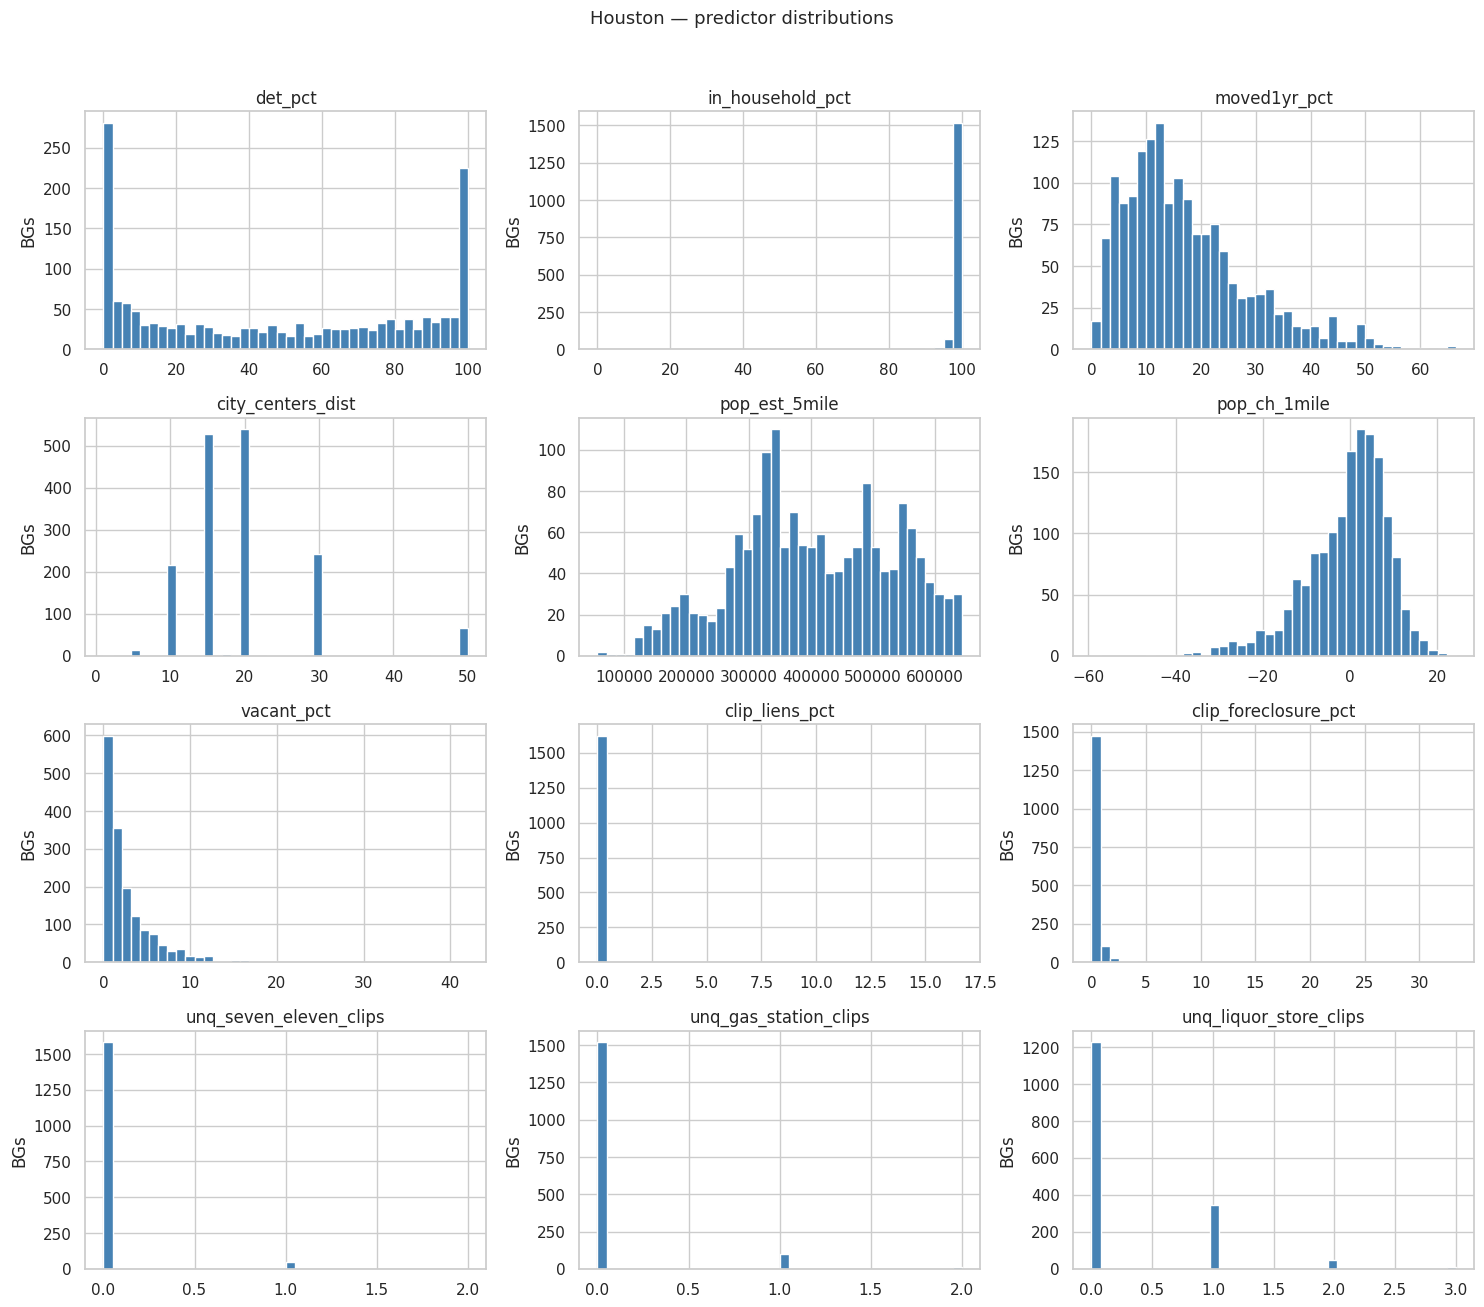

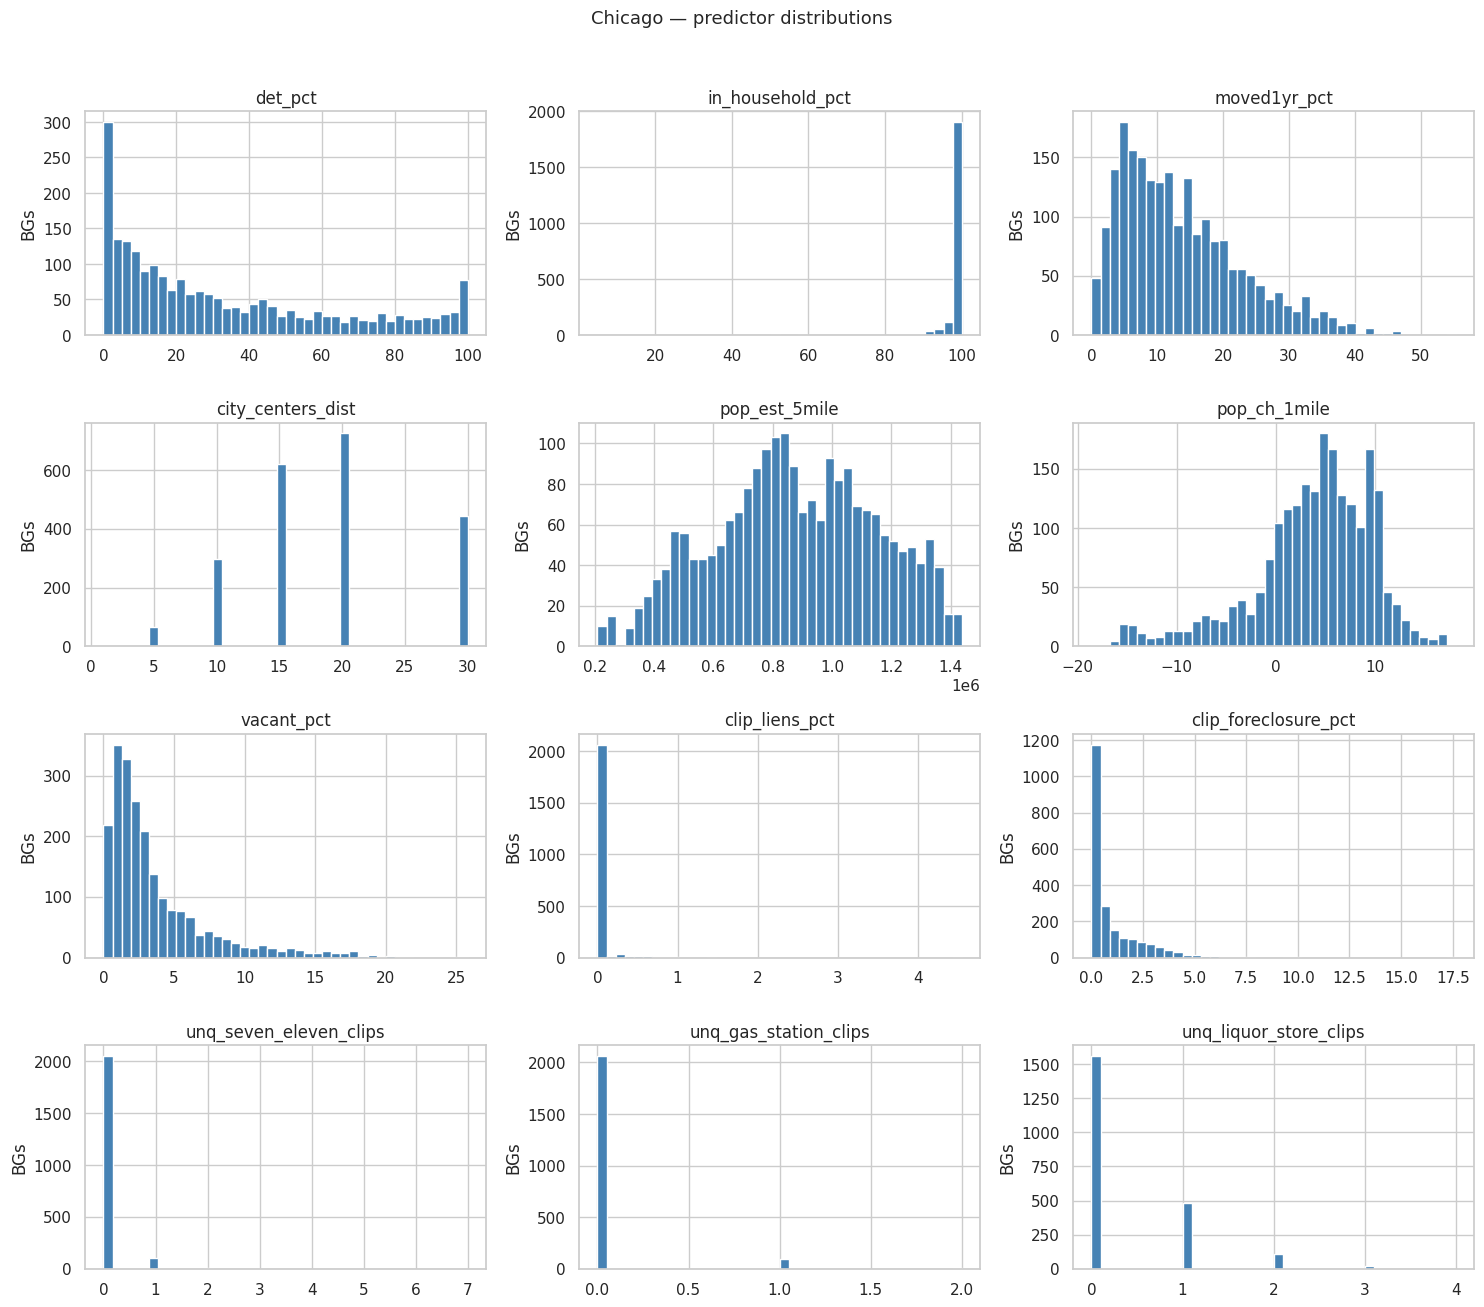

In [19]:
# Predictor distributions
def plot_grid(df, cols, title, bins=40, color="steelblue"):
    ncol = 3
    nrow = int(np.ceil(len(cols) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.2 * nrow))
    for ax, c in zip(axes.ravel(), cols):
        ax.hist(df[c].dropna(), bins=bins, color=color, edgecolor="white")
        ax.set_title(c); ax.set_ylabel("BGs")
    for ax in axes.ravel()[len(cols):]:
        ax.set_visible(False)
    fig.suptitle(title, fontsize=13, y=1.02); fig.tight_layout(); plt.show()

for city, df in tables.items():
    plot_grid(df, PREDICTOR_COLS, f"{city.title()} — predictor distributions")

In [20]:
# Target summary
# pct_zero is the key column: a target with very high zero-fraction is a poor
# candidate for OLS on log-count and may need pooling or a count model.
def target_summary(df):
    rows = []
    for c in TARGET_CATEGORIES:
        cnt = df[f"{c}_count"]
        rows.append({
            "target": c, "total": int(cnt.sum()), "mean": round(cnt.mean(), 2),
            "p50": cnt.median(), "p95": cnt.quantile(.95), "max": cnt.max(),
            "pct_zero": round((cnt == 0).mean() * 100, 1), "skew": round(cnt.skew(), 2),
        })
    return pd.DataFrame(rows)

for city, df in tables.items():
    print(f"\n{city.upper()} — target (count) summary")
    display(target_summary(df))


HOUSTON — target (count) summary


,target,total,mean,p50,p95,max,pct_zero,skew
0,cl_total,107678,66.10,42.0,205.0,1014.0,2.7,4.13
1,violent,19555,12.00,8.0,36.0,127.0,8.0,2.56
2,property,88123,54.10,33.0,177.0,967.0,3.1,4.52
3,assault,12614,7.74,5.0,25.0,86.0,11.8,2.50
4,murder,278,0.17,0.0,1.0,4.0,86.1,3.06
5,rape,1841,1.13,1.0,4.0,39.0,47.0,7.18
6,robbery,4822,2.96,1.0,11.0,37.0,30.9,2.48
7,burglary,10946,6.72,5.0,21.0,48.0,11.4,1.97
8,larceny,65385,40.14,20.0,144.4,912.0,4.1,5.06
9,mvt,11792,7.24,5.0,22.0,163.0,10.3,5.57



CHICAGO — target (count) summary


,target,total,mean,p50,p95,max,pct_zero,skew
0,cl_total,102722,47.47,32.0,124.0,1581.0,0.2,9.76
1,violent,21553,9.96,6.0,33.0,186.0,7.3,3.46
2,property,81169,37.51,25.0,99.0,1395.0,0.2,10.29
3,assault,13591,6.28,4.0,21.0,90.0,13.3,2.65
4,murder,429,0.20,0.0,1.0,5.0,85.0,3.66
5,rape,1786,0.83,0.0,3.0,55.0,57.4,12.88
6,robbery,5747,2.66,1.0,9.0,87.0,29.7,6.41
7,burglary,6130,2.83,2.0,8.0,25.0,18.4,2.22
8,larceny,57954,26.78,15.0,78.0,1299.0,0.5,11.32
9,mvt,17085,7.90,6.0,21.0,123.0,4.3,3.79


1. **Large pct_zero** values for murder and rape, as one would expect
2. Block groups with Robbery and Burglary now seem in line after data refresh! 

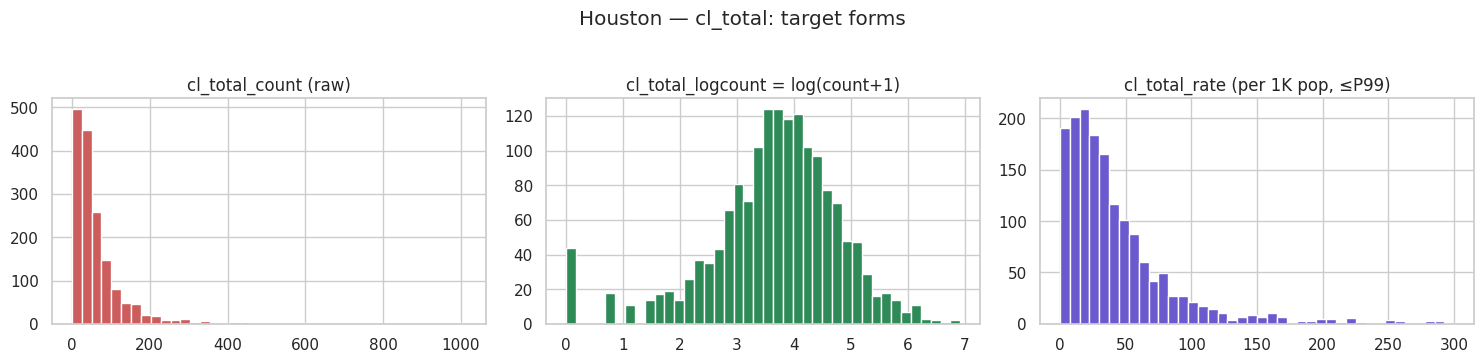

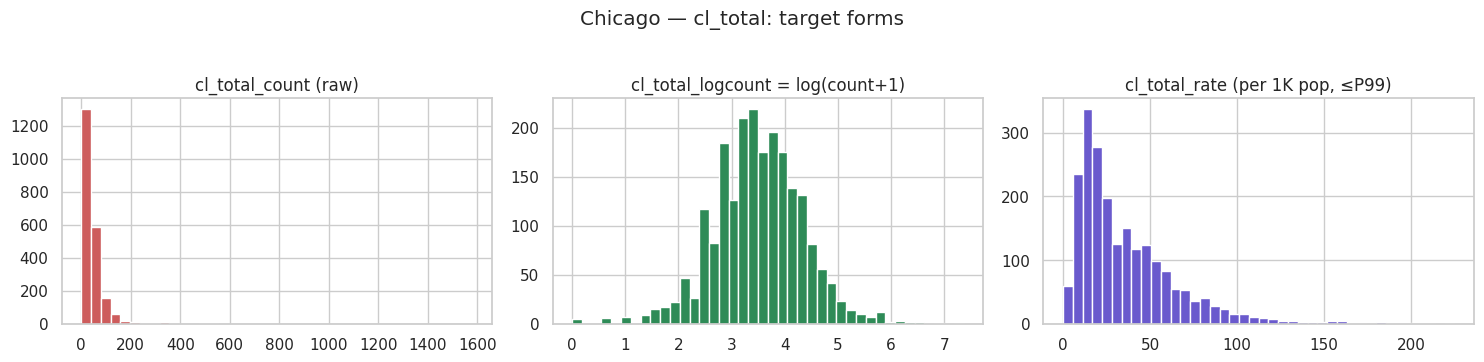

In [21]:
# Confirms log(count+1) tames the skew that raw counts show — justifying the OLS target.
def plot_target_forms(df, cat, city, rate_clip_pct=99):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    axes[0].hist(df[f"{cat}_count"], bins=40, color="indianred", edgecolor="white")
    axes[0].set_title(f"{cat}_count (raw)")
    axes[1].hist(df[f"{cat}_logcount"], bins=40, color="seagreen", edgecolor="white")
    axes[1].set_title(f"{cat}_logcount = log(count+1)")

    rate = df[f"{cat}_rate"].dropna()
    rate_range = (0, rate.quantile(rate_clip_pct / 100)) if rate_clip_pct else None
    axes[2].hist(rate, bins=40, range=rate_range, color="slateblue", edgecolor="white")
    axes[2].set_title(f"{cat}_rate (per 1K pop, ≤P{rate_clip_pct})")

    fig.suptitle(f"{city} — {cat}: target forms", y=1.03); fig.tight_layout(); plt.show()

for city, df in tables.items():
    plot_target_forms(df, "cl_total", city.title())

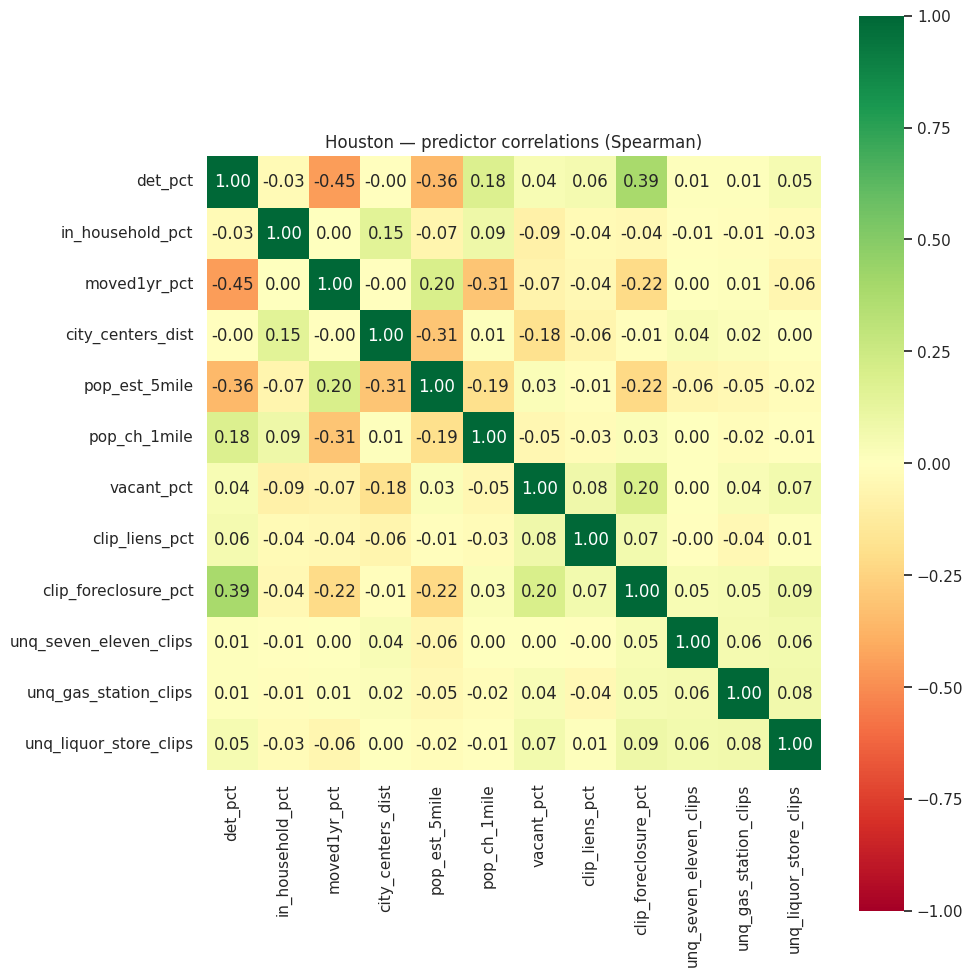

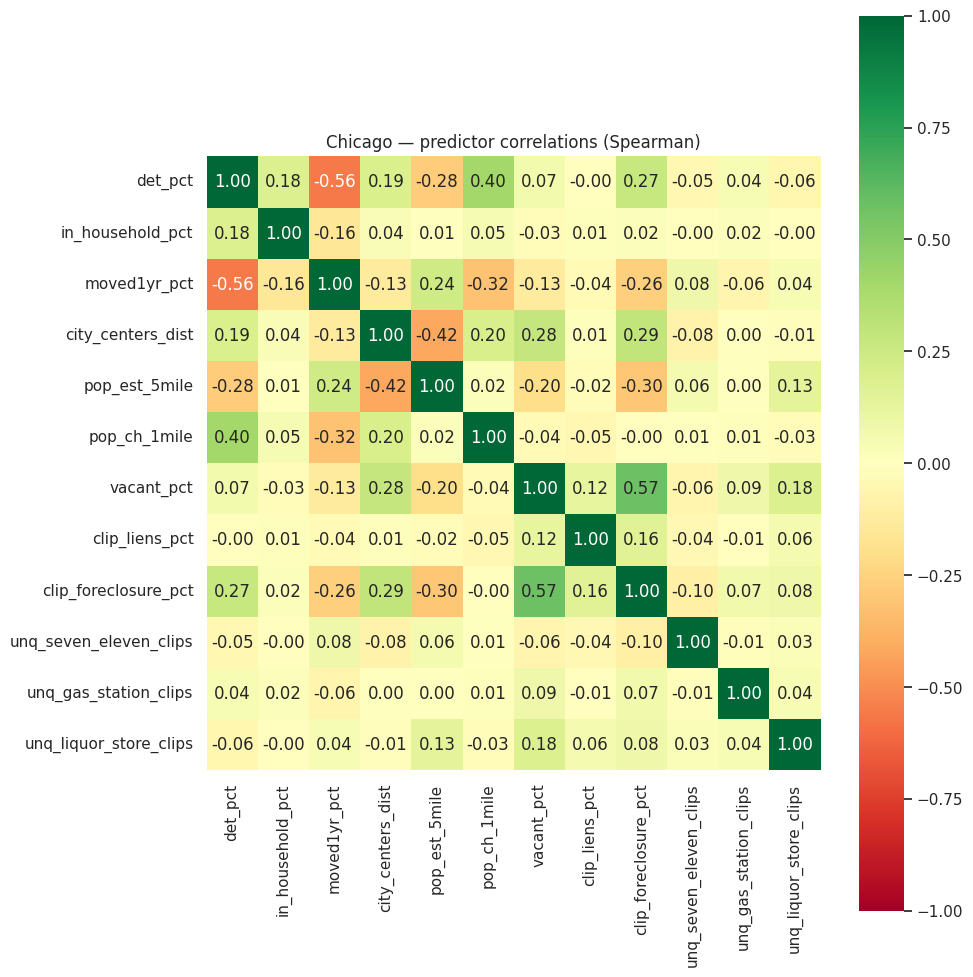

In [22]:
# Correlation heatmap
def corr_heatmap(df, cols, title):
    corr = df[cols].corr(method="spearman")
    fig, ax = plt.subplots(figsize=(10, 12))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8}, ax=ax)
    ax.set_title(title); plt.tight_layout(); plt.show()

for city, df in tables.items():
    corr_heatmap(df, PREDICTOR_COLS, f"{city.title()} — predictor correlations (Spearman)")

In [23]:
df[PREDICTOR_COLS].dtypes

det_pct                   float64
in_household_pct          float64
moved1yr_pct              float64
city_centers_dist         float64
pop_est_5mile             float64
pop_ch_1mile              float64
vacant_pct                float64
clip_liens_pct            float64
clip_foreclosure_pct      float64
unq_seven_eleven_clips    float64
unq_gas_station_clips     float64
unq_liquor_store_clips    float64
dtype: object

In [24]:
# VIF calculation

def vif_table(df, cols):
    Xnum = df[cols].apply(pd.to_numeric, errors="coerce").astype("float64")
    X = add_constant(df[cols].fillna(df[cols].median()))
    vif = pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    })
    return vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).round(2)

for city, df in tables.items():
    print(f"\n{city.upper()} — VIF")
    display(vif_table(df, PREDICTOR_COLS))


HOUSTON — VIF


,feature,VIF
5,pop_est_5mile,1.47
1,det_pct,1.43
3,moved1yr_pct,1.38
4,city_centers_dist,1.32
6,pop_ch_1mile,1.18
7,vacant_pct,1.09
2,in_household_pct,1.08
12,unq_liquor_store_clips,1.02
10,unq_seven_eleven_clips,1.02
9,clip_foreclosure_pct,1.01



CHICAGO — VIF


,feature,VIF
7,vacant_pct,1.73
9,clip_foreclosure_pct,1.62
3,moved1yr_pct,1.60
1,det_pct,1.59
5,pop_est_5mile,1.53
4,city_centers_dist,1.47
6,pop_ch_1mile,1.42
2,in_household_pct,1.13
12,unq_liquor_store_clips,1.07
10,unq_seven_eleven_clips,1.07


In [25]:
# Spearman of each predictor against each target (log-count). Directional preview
# of which predictors carry signal before fitting.
def predictor_target_corr(df, targets, suffix):
    tcols = [f"{t}_{suffix}" for t in targets]
    corr = df[PREDICTOR_COLS + tcols].corr(method="spearman").loc[PREDICTOR_COLS, tcols]
    corr.columns = targets
    return corr.round(2)

for city, df in tables.items():
    print(f"\n{city.upper()} — predictor vs target (Spearman, log-count)")
    display(predictor_target_corr(df, TARGET_CATEGORIES, "logcount"))


HOUSTON — predictor vs target (Spearman, log-count)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
det_pct,-0.16,-0.09,-0.17,-0.07,-0.02,-0.08,-0.09,-0.04,-0.17,-0.18
in_household_pct,-0.10,-0.11,-0.09,-0.11,-0.09,-0.09,-0.10,-0.09,-0.09,-0.04
moved1yr_pct,0.14,-0.05,0.18,-0.06,-0.01,0.02,-0.03,0.04,0.19,0.13
city_centers_dist,-0.18,-0.14,-0.18,-0.13,-0.07,-0.08,-0.13,-0.14,-0.18,-0.13
pop_est_5mile,0.14,0.04,0.16,-0.01,0.02,0.01,0.12,0.11,0.17,0.08
pop_ch_1mile,-0.15,0.03,-0.17,0.06,-0.02,-0.07,0.01,-0.07,-0.19,-0.08
vacant_pct,0.27,0.35,0.23,0.35,0.15,0.22,0.27,0.31,0.21,0.18
clip_liens_pct,0.06,0.04,0.05,0.05,0.06,0.01,0.03,0.06,0.05,0.03
clip_foreclosure_pct,0.10,0.18,0.06,0.19,0.11,0.09,0.10,0.17,0.05,0.04
unq_seven_eleven_clips,0.06,0.07,0.06,0.07,0.03,0.02,0.04,0.07,0.05,0.05



CHICAGO — predictor vs target (Spearman, log-count)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
det_pct,-0.31,-0.20,-0.32,-0.14,-0.07,-0.21,-0.20,-0.13,-0.38,-0.10
in_household_pct,-0.11,-0.09,-0.11,-0.08,-0.06,-0.10,-0.07,-0.06,-0.12,-0.05
moved1yr_pct,0.20,0.00,0.25,-0.06,-0.04,0.09,0.09,0.10,0.31,0.02
city_centers_dist,0.01,0.10,-0.00,0.14,-0.01,0.00,0.02,0.07,-0.05,0.09
pop_est_5mile,-0.05,-0.09,-0.04,-0.14,-0.05,-0.01,0.01,-0.05,0.04,-0.19
pop_ch_1mile,-0.29,-0.22,-0.28,-0.18,-0.09,-0.16,-0.22,-0.17,-0.28,-0.19
vacant_pct,0.39,0.52,0.30,0.54,0.27,0.24,0.36,0.26,0.21,0.41
clip_liens_pct,0.12,0.14,0.10,0.14,0.09,0.04,0.13,0.09,0.08,0.13
clip_foreclosure_pct,0.27,0.46,0.18,0.50,0.28,0.17,0.32,0.22,0.07,0.38
unq_seven_eleven_clips,0.03,-0.02,0.05,-0.04,-0.04,0.03,0.02,0.05,0.06,-0.02


In [26]:
# Correlations with rate
suffix="rate"
for city, df in tables.items():
    print(f"\n{city.upper()} — predictor vs target (Spearman, {suffix})")
    display(predictor_target_corr(df, TARGET_CATEGORIES, f"{suffix}"))


HOUSTON — predictor vs target (Spearman, rate)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
det_pct,-0.24,-0.16,-0.25,-0.13,-0.02,-0.11,-0.13,-0.10,-0.23,-0.26
in_household_pct,-0.08,-0.09,-0.07,-0.09,-0.09,-0.07,-0.08,-0.06,-0.08,-0.02
moved1yr_pct,0.19,-0.02,0.23,-0.04,-0.01,0.03,-0.01,0.06,0.24,0.18
city_centers_dist,-0.21,-0.16,-0.21,-0.15,-0.07,-0.09,-0.14,-0.16,-0.20,-0.16
pop_est_5mile,0.19,0.08,0.21,0.03,0.02,0.03,0.14,0.15,0.21,0.13
pop_ch_1mile,-0.17,0.02,-0.20,0.05,-0.02,-0.07,-0.00,-0.08,-0.21,-0.11
vacant_pct,0.32,0.41,0.28,0.40,0.15,0.24,0.30,0.36,0.26,0.23
clip_liens_pct,0.07,0.05,0.06,0.05,0.06,-0.00,0.03,0.06,0.06,0.04
clip_foreclosure_pct,0.04,0.13,0.01,0.14,0.11,0.07,0.07,0.12,0.00,-0.01
unq_seven_eleven_clips,0.03,0.04,0.03,0.05,0.03,0.00,0.03,0.05,0.03,0.02



CHICAGO — predictor vs target (Spearman, rate)


,cl_total,violent,property,assault,murder,rape,robbery,burglary,larceny,mvt
det_pct,-0.24,-0.15,-0.25,-0.09,-0.06,-0.18,-0.17,-0.07,-0.31,-0.04
in_household_pct,-0.10,-0.08,-0.10,-0.07,-0.06,-0.10,-0.05,-0.05,-0.11,-0.04
moved1yr_pct,0.18,-0.01,0.23,-0.08,-0.04,0.07,0.07,0.07,0.29,-0.00
city_centers_dist,0.13,0.18,0.11,0.21,-0.00,0.04,0.08,0.16,0.06,0.19
pop_est_5mile,-0.12,-0.14,-0.12,-0.18,-0.05,-0.03,-0.04,-0.11,-0.04,-0.25
pop_ch_1mile,-0.27,-0.20,-0.27,-0.16,-0.08,-0.15,-0.21,-0.15,-0.28,-0.16
vacant_pct,0.50,0.59,0.43,0.60,0.28,0.28,0.42,0.35,0.34,0.50
clip_liens_pct,0.12,0.13,0.10,0.13,0.09,0.05,0.12,0.08,0.08,0.13
clip_foreclosure_pct,0.39,0.53,0.31,0.55,0.30,0.21,0.38,0.30,0.20,0.47
unq_seven_eleven_clips,-0.02,-0.06,-0.01,-0.08,-0.04,0.01,-0.01,0.00,0.02,-0.07
